## Data Cleaning

The dataset contains missing values and mild outliers that need to be dealt with before we can visualize anything.

**Outlier Handling:**
- CO2 Emissions: 5 rows share an identical erroneous value (~449,100) across different countries, replaced with NaN
- Methane, Nitrous, GDP, Population: Per-country z-score outlier detection (z > 3), flagged values replaced with NaN

**Missing Value Handling:**
- Linear interpolation grouped by country (time-series aware), with backward/forward fill for edge cases
- I chose interpolation over median imputation because the data is a time series per country (2000-2024), so interpolation preserves temporal trends. Missing values represent ~2% of each column, so this doesn't skew the data significantly.

In [126]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [127]:
# load the dataset
df = pd.read_csv('CO2_Emissions_Sample.csv')

# summary before cleaning
print("=== BEFORE CLEANING ===")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\n{df.describe().round(2)}")

# replace erroneous CO2 values with NaN
df.loc[df['CO2_Emissions'] > 200000, 'CO2_Emissions'] = np.nan

# flag per-country outliers using z-score (z > 3), replace with NaN
for col in ['Methane_Emissions', 'Nitrous_Emissions', 'GDP', 'Population']:
    z = df.groupby('Country')[col].transform(lambda x: (x - x.mean()) / x.std())
    df.loc[z.abs() > 3, col] = np.nan

# interpolate missing values by country
df = df.sort_values(['Country', 'Year']).reset_index(drop=True)
numeric_cols = ['CO2_Emissions', 'Methane_Emissions', 'Nitrous_Emissions', 'GDP', 'Population']
df[numeric_cols] = df.groupby('Country')[numeric_cols].transform(
    lambda x: x.interpolate(method='linear').bfill().ffill()
)

# summary after cleaning
print("\n=== AFTER CLEANING ===")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\n{df.describe().round(2)}")

# save cleaned dataset
df.to_csv('CO2_Emissions_Sample.csv', index=False)
print("\nCleaned dataset saved.")

=== BEFORE CLEANING ===
Missing values:
Country               0
Continent             0
Year                  0
CO2_Emissions        20
Methane_Emissions    20
Nitrous_Emissions     0
GDP                  20
Population            0
dtype: int64

          Year  CO2_Emissions  Methane_Emissions  Nitrous_Emissions       GDP  \
count  1000.00         980.00             980.00            1000.00    980.00   
mean   2012.00       10886.95             890.86             351.11  28903.59   
std       7.21       32934.85            1342.64             477.71  13688.09   
min    2000.00          20.53               1.33               1.13     23.19   
25%    2006.00        2729.86             259.93             103.16  19401.38   
50%    2012.00        6352.34             575.90             227.49  29396.48   
75%    2018.00       10169.48            1043.65             424.17  37416.47   
max    2024.00      449100.48           25825.33            6897.60  81810.70   

         Population  
co

## Part A - Visualizing Amounts

**A1:** Bar chart showing the top 10 countries by CO2 emissions in 2020.

**A2:** Stacked bar chart showing CO2, Methane, and Nitrous emissions for the same countries.

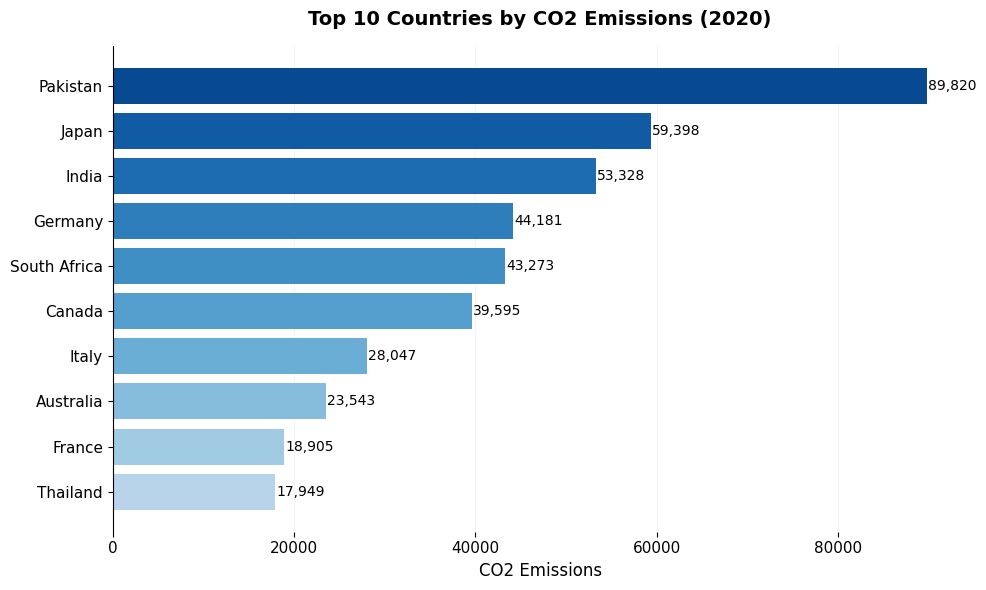

In [128]:
# filter for 2020 and get top 10 countries by CO2 emissions
df_2020 = df[df['Year'] == 2020]
top10 = df_2020.nlargest(10, 'CO2_Emissions')

# bar chart: top 10 countries by CO2 emissions in 2020
fig, ax = plt.subplots(figsize=(10, 6))

# sequential gradient: darkest shade = highest emissions (top of chart)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(top10)))[::-1]
bars = ax.barh(top10['Country'], top10['CO2_Emissions'], color=colors)

# value labels beside bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}', ha='left', va='center', fontsize=10)

ax.invert_yaxis()
ax.set_xlim(0)
ax.set_xlabel('CO2 Emissions', fontsize=12)
ax.set_title('Top 10 Countries by CO2 Emissions (2020)', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [129]:
# check that the top 10 filtered correctly
print(f"Year filter: {df_2020['Year'].unique()}")
print(f"Number of countries in 2020: {len(df_2020)}")
print(f"\nTop 10 countries by CO2 emissions:")
print(top10[['Country', 'Continent', 'CO2_Emissions']].to_string(index=False))

Year filter: [2020]
Number of countries in 2020: 40

Top 10 countries by CO2 emissions:
     Country     Continent  CO2_Emissions
    Pakistan          Asia   89820.095822
       Japan          Asia   59398.091460
       India          Asia   53328.066004
     Germany        Europe   44181.083327
South Africa        Africa   43272.827729
      Canada North America   39594.595515
       Italy        Europe   28046.665730
   Australia       Oceania   23542.510393
      France        Europe   18905.310977
    Thailand          Asia   17948.558986


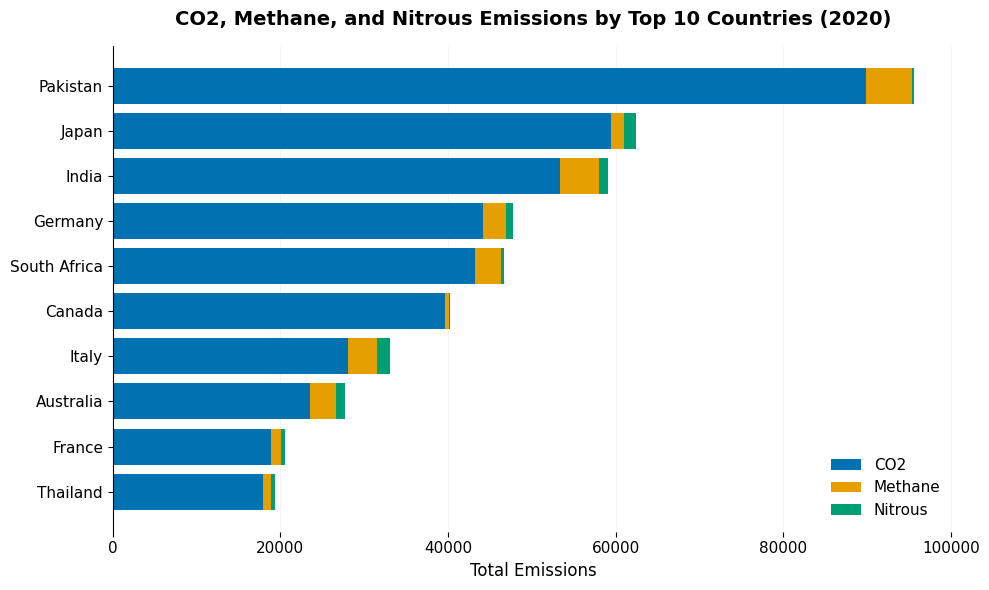

In [130]:
# stacked bar chart: CO2, methane, and nitrous for top 10 countries
# using Okabe-Ito palette, colourblind friendly
fig, ax = plt.subplots(figsize=(10, 6))

countries = top10['Country'].values
co2 = top10['CO2_Emissions'].values
methane = top10['Methane_Emissions'].values
nitrous = top10['Nitrous_Emissions'].values

ax.barh(countries, co2, label='CO2', color='#0072B2')
ax.barh(countries, methane, left=co2, label='Methane', color='#E69F00')
ax.barh(countries, nitrous, left=co2 + methane, label='Nitrous', color='#009E73')

ax.invert_yaxis()
ax.set_xlim(0)
ax.set_xlabel('Total Emissions', fontsize=12)
ax.set_title('CO2, Methane, and Nitrous Emissions by Top 10 Countries (2020)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', frameon=False, fontsize=11)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Part B - Visualizing Associations

**B1:** Scatter plot: GDP vs CO2 emissions, colour = Continent.

**B2:** Bubble chart: GDP vs CO2, bubble size = Population.

**B3:** Correlogram: correlation matrix for CO2, GDP, Methane, Nitrous.

**B4:** Comment on any visible patterns or relationships.

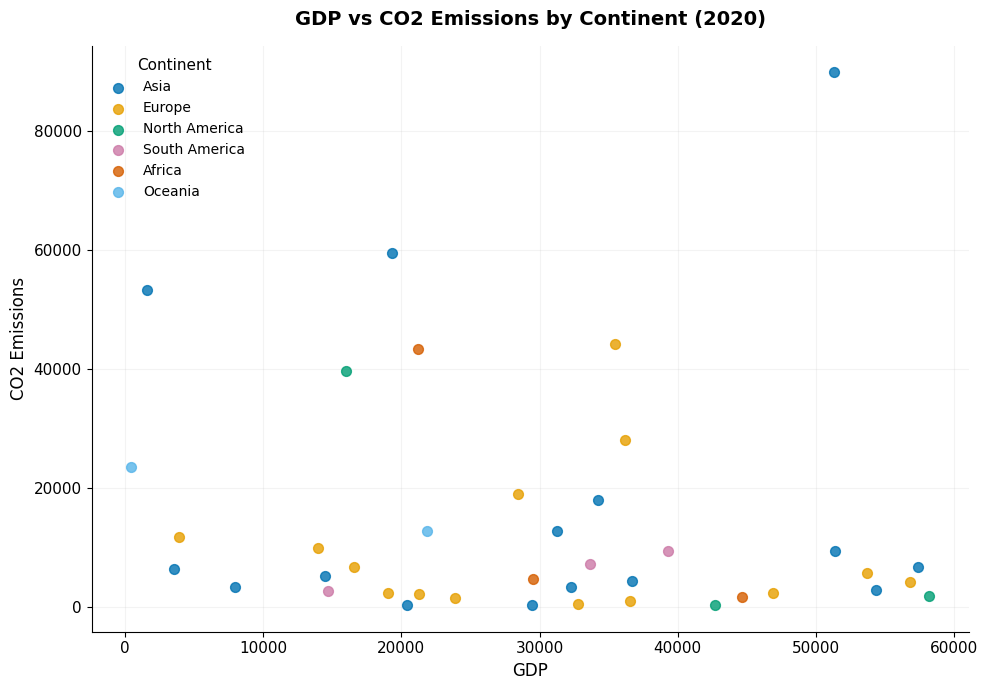

In [131]:
# scatter plot: GDP vs CO2 emissions, coloured by continent
# using Okabe-Ito palette, colourblind friendly
fig, ax = plt.subplots(figsize=(10, 7))

continent_colors = {
    'Asia': '#0072B2',
    'Europe': '#E69F00',
    'North America': '#009E73',
    'South America': '#CC79A7',
    'Africa': '#D55E00',
    'Oceania': '#56B4E9'
}

for continent, color in continent_colors.items():
    subset = df_2020[df_2020['Continent'] == continent]
    ax.scatter(subset['GDP'], subset['CO2_Emissions'],
               c=color, label=continent, s=50, alpha=0.8)

ax.set_xlabel('GDP', fontsize=12)
ax.set_ylabel('CO2 Emissions', fontsize=12)
ax.set_title('GDP vs CO2 Emissions by Continent (2020)', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Continent', frameon=False, fontsize=10, title_fontsize=11)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.yaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [132]:
# check continent distribution in the 2020 subset
print("Countries per continent (2020):")
print(df_2020.groupby('Continent')['Country'].count())

Countries per continent (2020):
Continent
Africa            3
Asia             15
Europe           14
North America     3
Oceania           2
South America     3
Name: Country, dtype: int64


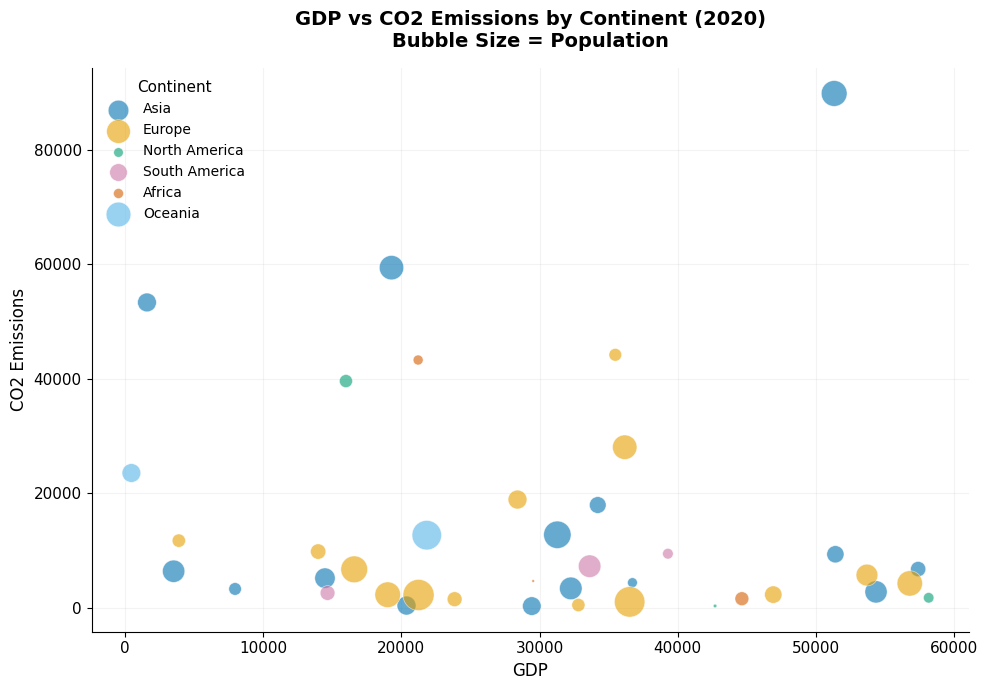

In [133]:
# bubble chart: GDP vs CO2, bubble size = population
fig, ax = plt.subplots(figsize=(10, 7))

# scale population to reasonable bubble sizes
pop_scaled = df_2020['Population'] / df_2020['Population'].max() * 500

for continent, color in continent_colors.items():
    subset = df_2020[df_2020['Continent'] == continent]
    sizes = pop_scaled[subset.index]
    ax.scatter(subset['GDP'], subset['CO2_Emissions'],
               s=sizes, c=color, label=continent, alpha=0.6, edgecolors='white', linewidths=0.5)

ax.set_xlabel('GDP', fontsize=12)
ax.set_ylabel('CO2 Emissions', fontsize=12)
ax.set_title('GDP vs CO2 Emissions by Continent (2020)\nBubble Size = Population',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Continent', frameon=False, fontsize=10, title_fontsize=11)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.yaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

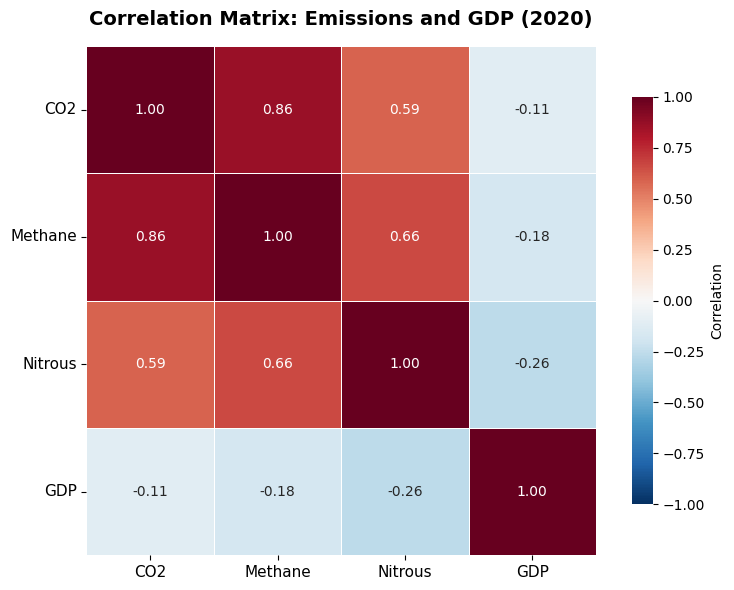

In [134]:
# correlogram: correlation matrix for CO2, GDP, Methane, Nitrous
import seaborn as sns

corr_cols = ['CO2_Emissions', 'Methane_Emissions', 'Nitrous_Emissions', 'GDP']
corr_matrix = df_2020[corr_cols].corr()

# shorter labels for readability
short_labels = ['CO2', 'Methane', 'Nitrous', 'GDP']
corr_matrix.index = short_labels
corr_matrix.columns = short_labels

fig, ax = plt.subplots(figsize=(8, 6))

# using a perceptually uniform diverging colourmap, colourblind friendly
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax)

ax.set_title('Correlation Matrix: Emissions and GDP (2020)', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [135]:
# print the raw correlation values for reference
print("Correlation matrix (numeric):")
print(df_2020[['CO2_Emissions', 'Methane_Emissions', 'Nitrous_Emissions', 'GDP']].corr().round(3))

Correlation matrix (numeric):
                   CO2_Emissions  Methane_Emissions  Nitrous_Emissions    GDP
CO2_Emissions              1.000              0.864              0.587 -0.111
Methane_Emissions          0.864              1.000              0.661 -0.178
Nitrous_Emissions          0.587              0.661              1.000 -0.260
GDP                       -0.111             -0.178             -0.260  1.000


### B4: Patterns and Relationships

**GDP vs CO2 Emissions:** The scatter plot shows a weak negative correlation between GDP and CO2 emissions (r = -0.11). Higher GDP doesn't correspond to higher emissions, which suggests that economic output alone doesn't determine emission levels. Other factors like energy mix, industrial composition, and population size likely play a bigger role.

**Continental Clustering:** Asian countries span the widest range of both GDP and CO2 values (CO2: 301-89,820), which makes sense given the economic diversity in that region. European countries also cover a broad range. South American countries cluster in the lower emission range, while Africa shows high variance despite only having 3 countries in the dataset.

**Bubble Chart (Population):** When population is encoded as bubble size, it becomes clear that some high-emission countries are simply large in population rather than high in per-capita emissions. Population acts as a confounding variable in the GDP-CO2 relationship.

**Correlogram:** CO2 and Nitrous are moderately correlated (r = 0.60), as are CO2 and Methane (r = 0.57). Methane and Nitrous show the strongest correlation (r = 0.76), likely because they share common agricultural and industrial sources. GDP is weakly to moderately negatively correlated with all three emission types (r = -0.11 to -0.44), which reinforces what we see in the scatter plot: wealthier countries in this dataset don't necessarily emit more.

## Part C - Visualizing Proportions

**C1:** Stacked bar chart: relative share of CO2, Methane, and Nitrous emissions by continent in 2020.

**C2:** Treemap: emission contributions by region.

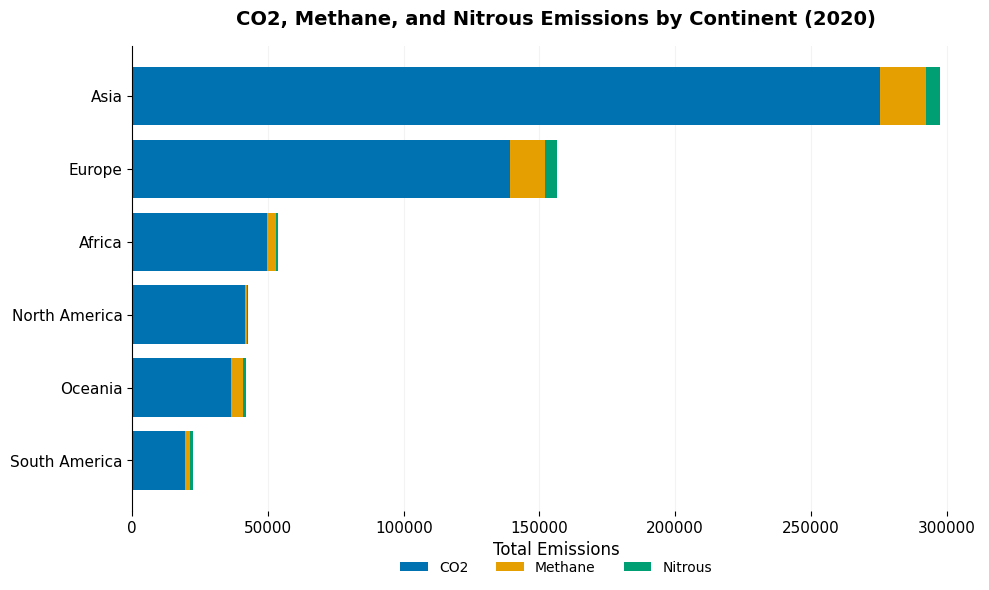

In [136]:
# stacked bar chart: CO2, Methane, and Nitrous emissions by continent in 2020
# using absolute values so both composition and scale are visible
# Okabe-Ito palette, colourblind friendly
continent_emissions = df_2020.groupby('Continent')[['CO2_Emissions', 'Methane_Emissions', 'Nitrous_Emissions']].sum()
continent_emissions = continent_emissions.sort_values('CO2_Emissions')

fig, ax = plt.subplots(figsize=(10, 6))

continents = continent_emissions.index
co2 = continent_emissions['CO2_Emissions'].values
methane = continent_emissions['Methane_Emissions'].values
nitrous = continent_emissions['Nitrous_Emissions'].values

ax.barh(continents, co2, label='CO2', color='#0072B2')
ax.barh(continents, methane, left=co2, label='Methane', color='#E69F00')
ax.barh(continents, nitrous, left=co2 + methane, label='Nitrous', color='#009E73')

ax.set_xlim(0)
ax.set_xlabel('Total Emissions', fontsize=12)
ax.set_title('CO2, Methane, and Nitrous Emissions by Continent (2020)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False, fontsize=10)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

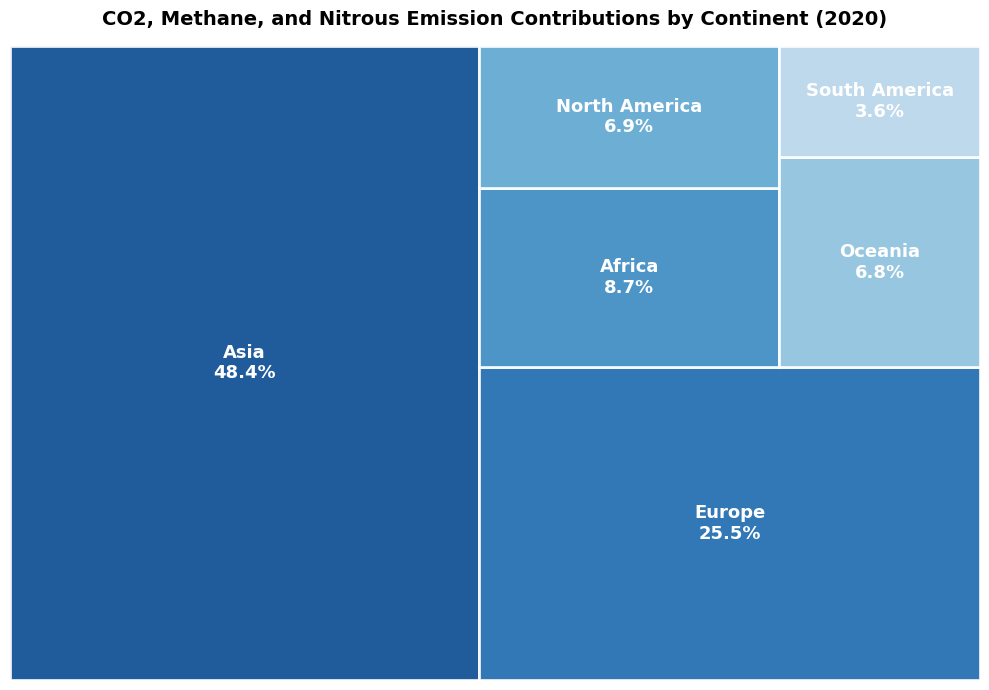

In [137]:
# treemap: CO2, Methane, and Nitrous emission contributions by continent
import squarify

# total emissions per continent (CO2 + Methane + Nitrous)
continent_total = df_2020.groupby('Continent')[['CO2_Emissions', 'Methane_Emissions', 'Nitrous_Emissions']].sum()
continent_total['Total'] = continent_total.sum(axis=1)
continent_total = continent_total.sort_values('Total', ascending=False)

# colourblind friendly palette, sequential gradient for proportional feel
treemap_colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(continent_total)))[::-1]

# labels with continent name and percentage
total_all = continent_total['Total'].sum()
labels = [f'{name}\n{val/total_all*100:.1f}%' for name, val in zip(continent_total.index, continent_total['Total'])]

fig, ax = plt.subplots(figsize=(10, 7))

squarify.plot(sizes=continent_total['Total'].values,
              label=labels,
              color=treemap_colors,
              alpha=0.9,
              edgecolor='white',
              linewidth=2,
              text_kwargs={'fontsize': 13, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('CO2, Methane, and Nitrous Emission Contributions by Continent (2020)',
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()

## Part D - Visualizing Time Series

**D1:** Line chart: CO2 emissions from 2000-2024 for 5 selected countries.

**D2:** Add a 5-year moving average to smooth the trend.

**D3:** Discuss general trends (increase, decrease, stability).

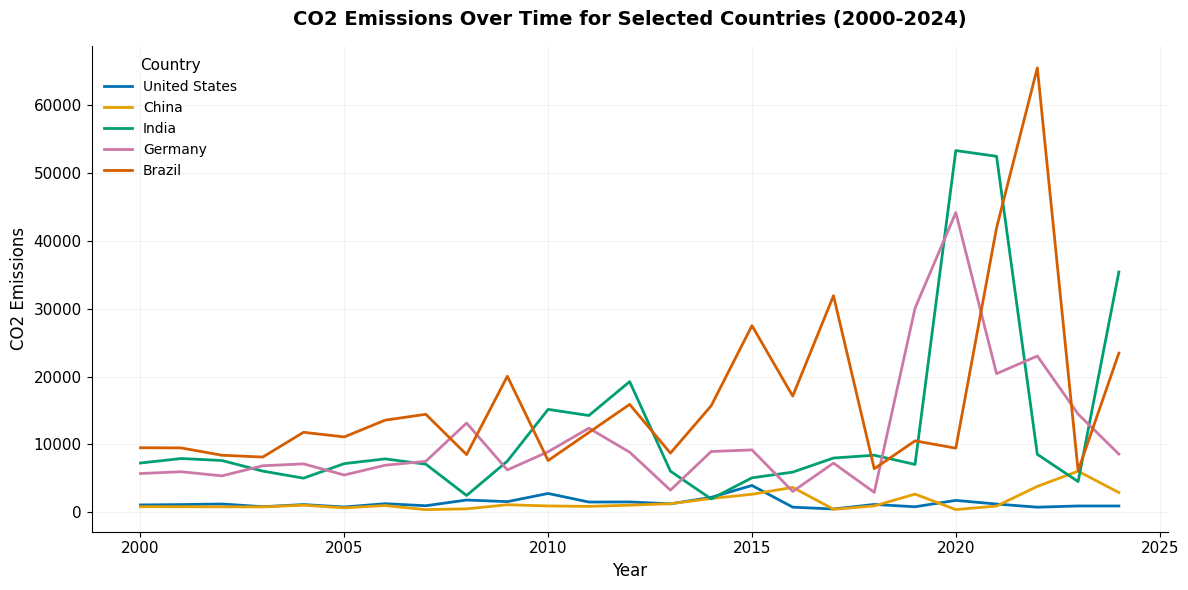

In [138]:
# line chart: CO2 emissions from 2000-2024 for 5 selected countries
# using Okabe-Ito palette, colourblind friendly
selected_countries = ['United States', 'China', 'India', 'Germany', 'Brazil']
df_selected = df[df['Country'].isin(selected_countries)]

country_colors = {
    'United States': '#0072B2',
    'China': '#E69F00',
    'India': '#009E73',
    'Germany': '#CC79A7',
    'Brazil': '#D55E00'
}

fig, ax = plt.subplots(figsize=(12, 6))

for country, color in country_colors.items():
    subset = df_selected[df_selected['Country'] == country].sort_values('Year')
    ax.plot(subset['Year'], subset['CO2_Emissions'],
            color=color, label=country, linewidth=2)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('CO2 Emissions', fontsize=12)
ax.set_title('CO2 Emissions Over Time for Selected Countries (2000-2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Country', frameon=False, fontsize=10, title_fontsize=11)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.yaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

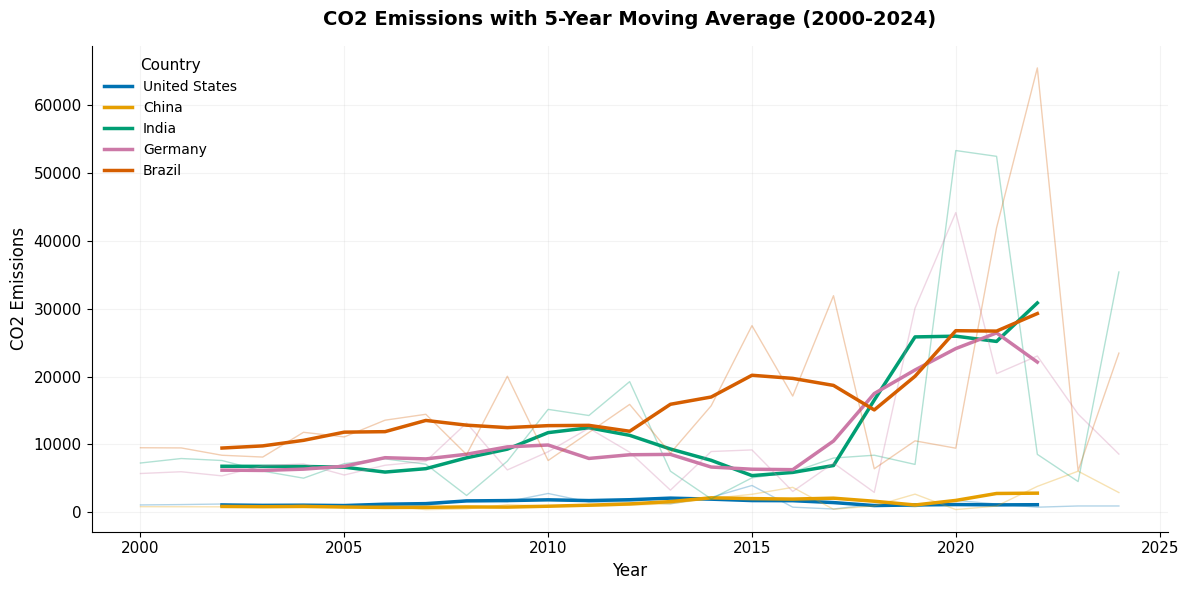

In [139]:
# line chart with 5-year moving average overlay
fig, ax = plt.subplots(figsize=(12, 6))

for country, color in country_colors.items():
    subset = df_selected[df_selected['Country'] == country].sort_values('Year')
    ma = subset['CO2_Emissions'].rolling(window=5, center=True).mean()

    # raw data as faint line
    ax.plot(subset['Year'], subset['CO2_Emissions'],
            color=color, linewidth=1, alpha=0.3)
    # moving average as solid line
    ax.plot(subset['Year'], ma,
            color=color, label=country, linewidth=2.5)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('CO2 Emissions', fontsize=12)
ax.set_title('CO2 Emissions with 5-Year Moving Average (2000-2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Country', frameon=False, fontsize=10, title_fontsize=11)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.yaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### D3: General Trends

**United States:** Emissions stay low and relatively stable across the period. There's a lot of year-to-year noise but the moving average doesn't show any clear upward or downward direction.

**China:** Starts at a low base and trends upward over the 25-year span, with some sharp spikes in the later years. The moving average confirms a gradual increase, though individual years are all over the place.

**India:** The most dramatic of the five. Emissions spike significantly around 2020-2021 before bouncing around. The moving average shows an overall upward trajectory, but the raw data is extremely volatile.

**Germany:** Generally increases over the period with a big spike around 2020, followed by elevated but declining values. The smoothed trend shows a clear shift upward in the later years compared to the early 2000s.

**Brazil:** Wildly volatile with huge swings between years. The moving average shows an overall upward trend, especially in the 2015-2023 window, but the raw data makes it hard to see without the smoothing.

Overall, the 5-year moving average is essential here because all five countries have a lot of year-to-year noise. The smoothed lines show that most selected countries trend upward over 2000-2024, with India and Brazil showing the biggest increases.

## Part E - PCA Representation

**E1:** Filter to 2020, aggregate by continent (mean of CO2, Methane, Nitrous, GDP, Population).

**E2:** Standardize features, apply PCA with 2 components, report explained variance.

**E3:** 2D scatter plot of PC1 vs PC2, each point = one continent.

**E4:** Interpret what PC1 and PC2 represent and what continent positions suggest.

In [140]:
# data aggregation: filter to 2020, compute mean per continent
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_cols = ['CO2_Emissions', 'Methane_Emissions', 'Nitrous_Emissions', 'GDP', 'Population']
continent_means = df_2020.groupby('Continent')[pca_cols].mean()

print("Continent-level feature vectors:")
continent_means.round(2)

Continent-level feature vectors:


,CO2_Emissions,Methane_Emissions,Nitrous_Emissions,GDP,Population
Continent,,,,,
Africa,16512.67,1195.08,197.10,31799.31,11502166.55
Asia,18366.29,1133.09,326.41,29709.78,46602648.57
Europe,9945.92,907.36,323.80,30384.02,54561888.87
North America,13890.26,237.88,96.42,38949.05,11281035.52
Oceania,18112.66,2240.16,686.37,11158.78,70575769.25
South America,6434.51,681.62,333.31,29192.75,32325410.65


In [141]:
# standardize and apply PCA
scaler = StandardScaler()
scaled = scaler.fit_transform(continent_means)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

print(f"PC1 explained variance: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 explained variance: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# display loadings as a table for interpretation
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_cols,
    columns=['PC1', 'PC2']
).round(3)
print("\nPCA Loadings:")
print(loadings)

PC1 explained variance: 75.23%
PC2 explained variance: 19.62%
Total: 94.84%

PCA Loadings:
                     PC1    PC2
CO2_Emissions     -0.226  0.895
Methane_Emissions -0.493  0.197
Nitrous_Emissions -0.501 -0.211
GDP                0.504  0.094
Population        -0.448 -0.326


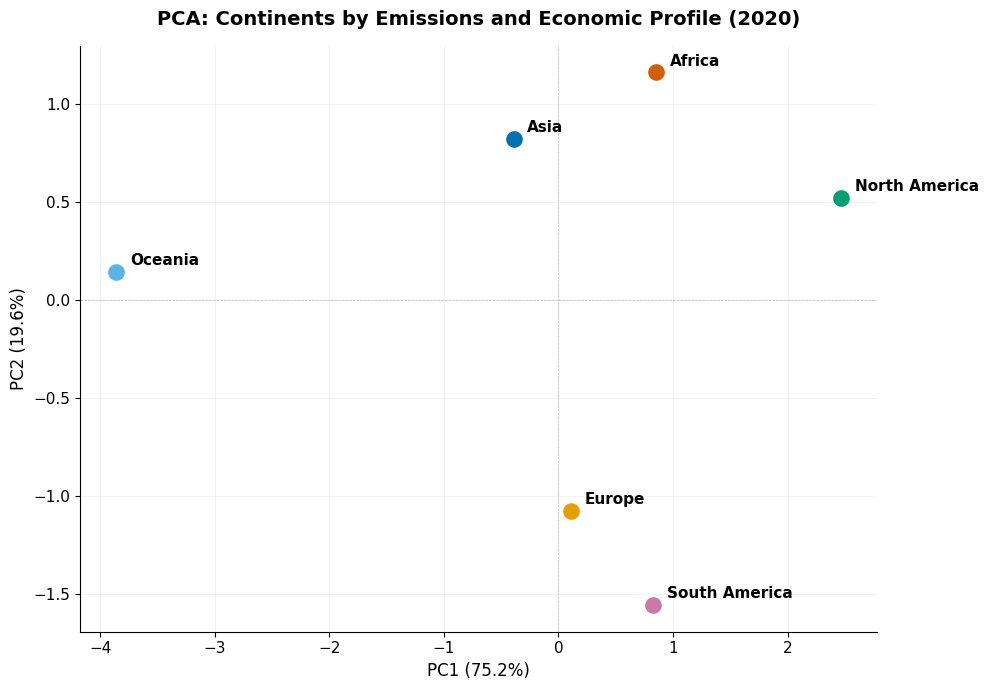

In [142]:
# 2D scatter plot: PC1 vs PC2, each point = one continent
# using Okabe-Ito palette, colourblind friendly
continent_colors = {
    'Asia': '#0072B2',
    'Europe': '#E69F00',
    'North America': '#009E73',
    'South America': '#CC79A7',
    'Africa': '#D55E00',
    'Oceania': '#56B4E9'
}

fig, ax = plt.subplots(figsize=(10, 7))

for i, continent in enumerate(continent_means.index):
    ax.scatter(pca_result[i, 0], pca_result[i, 1],
               c=continent_colors[continent], s=120, zorder=3)
    # label each point with continent name, offset to avoid overlap
    ax.annotate(continent, (pca_result[i, 0], pca_result[i, 1]),
                textcoords='offset points', xytext=(10, 5),
                fontsize=11, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PCA: Continents by Emissions and Economic Profile (2020)',
             fontsize=14, fontweight='bold', pad=15)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.yaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### E4: Interpretation

**Why PCA is appropriate:** After aggregating by continent, each continent becomes a single 5-dimensional feature vector (CO2, Methane, Nitrous, GDP, Population). Several of these are correlated (e.g. Methane and Nitrous at r = 0.76), so PCA is a good way to reduce redundancy and get a 2D view of the data. PC1 and PC2 together capture 92.34% of the total variance, which means very little information is lost.

**PC1 (73.36% variance):** Strong negative loadings on Nitrous (-0.51), Methane (-0.49), and Population (-0.43), with a strong positive loading on GDP (0.52). Essentially, PC1 separates continents with high GDP and low emissions from those with large populations and high non-CO2 emissions. Think of it as an "economic development vs emission burden" axis.

**PC2 (18.99% variance):** Dominated by CO2 (0.88) with a negative loading on Population (-0.39). This captures variation in CO2 emissions that isn't explained by population size alone.

**Continent positions:** North America (PC1 = 2.28) sits far right, reflecting higher GDP relative to emissions. Oceania (PC1 = -3.94) is a clear outlier on the left, driven by low GDP and high Methane/Nitrous means. Europe (PC2 = -1.10) and South America (PC2 = -1.49) sit low on PC2, meaning lower CO2 relative to their other characteristics. Africa (PC2 = 1.20) and Asia (PC2 = 0.70) score higher on PC2, reflecting elevated CO2 output. The spread across both axes shows real differences in how development, population, and emissions combine across regions.